# Homework: Exploratory Data Analysis of Time Series Data

## Dataset: Hourly Electricity Consumption

### Background

Electricity consumption is a classic time series problem. Demand changes over time because of human activity, working hours, weekends, holidays, weather, and seasonal effects. In this homework, you will perform an exploratory data analysis of hourly electricity consumption data.

The goal is **not** to build a forecasting model yet. The goal is to understand the data, identify patterns, detect problems, and prepare the dataset for future modeling.

## Dataset

Use the Kaggle dataset:

**Hourly Energy Consumption**  
Recommended file: `AEP_hourly.csv`  
Kaggle dataset: <https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption>

You may download it manually from Kaggle, or use the Kaggle API:

```bash
kaggle datasets download -d robikscube/hourly-energy-consumption
```

The recommended file usually contains the following columns:

| Column | Meaning |
|---|---|
| `Datetime` | Timestamp of the observation |
| `AEP_MW` | Electricity consumption in megawatts |

## Learning Goals

By the end of this assignment, you should be able to:

1. Load and inspect a time series dataset.
2. Convert a date column into a proper datetime index.
3. Detect missing values, duplicate timestamps, and irregular time intervals.
4. Visualize long-term and short-term time series patterns.
5. Analyze trend, seasonality, distribution, autocorrelation, and stationarity.
6. Summarize EDA findings clearly and prepare the data for forecasting.

---

# Part 1: Loading and Initial Inspection

1. Load the CSV file using `pandas`.
2. Display the first 10 rows.
3. Print the shape of the dataset.
4. Print the column names.
5. Check the data types of all columns.
6. Convert the date/time column into a `datetime` object.
7. Set the datetime column as the DataFrame index.
8. Sort the data by time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("data/AEP_hourly.csv")

display(df.head(10))
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types before conversion:")
print(df.dtypes)

datetime_col = df.columns[0]
df[datetime_col] = pd.to_datetime(df[datetime_col])
df = df.set_index(datetime_col).sort_index()

display(df.head())
print("Index type:", df.index.dtype)




,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
5,2004-12-31 06:00:00,13038.0
6,2004-12-31 07:00:00,13692.0
7,2004-12-31 08:00:00,14297.0
8,2004-12-31 09:00:00,14719.0
9,2004-12-31 10:00:00,14941.0


Shape: (121273, 2)
Columns: ['Datetime', 'AEP_MW']
Data types before conversion:
Datetime     object
AEP_MW      float64
dtype: object


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


Index type: datetime64[ns]


---

# Part 2: Time Index Analysis

Answer the following questions:

1. What is the first timestamp in the dataset?
2. What is the last timestamp in the dataset?
3. What is the total time span of the data?
4. What is the frequency of the data?
5. Are there duplicated timestamps?
6. Are there missing timestamps?

You should check whether the data is really hourly.

In [7]:
print("the first timestamp:", df.index.min())
print("the last timestamp:", df.index.max())
print("Time span:", df.index.max() - df.index.min())
print("Time span in years:", round((df.index.max() - df.index.min()).days / 365.25, 3), "years")
print("Frequency:", pd.infer_freq(df.index))
print("Duplicated timestamps:", df.index.duplicated().sum())
print("Missing data:", df.index.isnull().sum())

## Duplicate
dups = df[df.index.duplicated(keep=False)].sort_index()
col = df.columns[0]

rows = []
for ts, group in dups.groupby(level=0):
    original = group.iloc[0][col]
    
    for dup_num in range(1, len(group)):
        duplicate = group.iloc[dup_num][col]
        
        rows.append({
            "timestamp": ts,
            "original": original,
            "duplicate": duplicate,
            "is_identical": duplicate == original
        })

comparison_table = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
print("\n", comparison_table)

df_no_duplicates = df[~df.index.duplicated(keep="last")].sort_index()
print("\nDuplicated timestamps:", df_no_duplicates.index.duplicated().sum())
print("Frequency:", pd.infer_freq(df_no_duplicates.index))

## Gaps
diffs = df_no_duplicates.index.to_series().diff()
print("\nGap counts:", diffs.value_counts().sort_index())

# Define expected hourly index
full_index = pd.date_range(
    start=df_no_duplicates.index.min(),
    end=df_no_duplicates.index.max(),
    freq="h")

# Find missing timestamps
missing_timestamps = full_index.difference(df_no_duplicates.index)
print("\nNumber of missing timestamps:", len(missing_timestamps))
print(missing_timestamps)

# add missing timestamps with NaN values
full_index = pd.date_range(df_no_duplicates.index.min(), df_no_duplicates.index.max(), freq="h")
df_no_gaps = df_no_duplicates.reindex(full_index)
missing_timestamps_no_gaps = full_index.difference(df_no_gaps.index)
print("\nNumber of missing timestamps:", len(missing_timestamps_no_gaps))
print(missing_timestamps_no_gaps)

# Check frequency
print("\nInferred frequency:", pd.infer_freq(df_no_gaps.index))


# the fix data
fix_data = df_no_gaps.copy().sort_index()
print(fix_data.head())
print("\nthe first timestamp:", fix_data.index.min())
print("the last timestamp:", fix_data.index.max())
print("Time span:", fix_data.index.max() - fix_data.index.min())
print("Time span in years:", round((fix_data.index.max() - fix_data.index.min()).days / 365.25, 3), "years")
print("shape of the data:", fix_data.shape)
print("Frequency:", pd.infer_freq(fix_data.index))
print("Duplicated timestamps:", fix_data.index.duplicated().sum())
print("Missing data:", fix_data.index.isnull().sum())

# Gaps
diffs = fix_data.index.to_series().diff()
print("\nGap counts:", diffs.value_counts().sort_index())

full_index = pd.date_range(
    start=fix_data.index.min(),
    end=fix_data.index.max(),
    freq="h")

missing_timestamps_fix_data = full_index.difference(fix_data.index)
print("\nNumber of missing timestamps:", len(missing_timestamps_fix_data))



the first timestamp: 2004-10-01 01:00:00
the last timestamp: 2018-08-03 00:00:00
Time span: 5053 days 23:00:00
Time span in years: 13.834 years
Frequency: None
Duplicated timestamps: 4
Missing data: 0

             timestamp  original  duplicate  is_identical
0 2014-11-02 02:00:00   12994.0    13190.0         False
1 2015-11-01 02:00:00   10785.0    10542.0         False
2 2016-11-06 02:00:00   10964.0    11008.0         False
3 2017-11-05 02:00:00   10596.0    10446.0         False

Duplicated timestamps: 0
Frequency: None

Gap counts: Datetime
0 days 01:00:00    121241
0 days 02:00:00        27
Name: count, dtype: int64

Number of missing timestamps: 27
DatetimeIndex(['2004-10-31 02:00:00', '2005-04-03 03:00:00',
               '2005-10-30 02:00:00', '2006-04-02 03:00:00',
               '2006-10-29 02:00:00', '2007-03-11 03:00:00',
               '2007-11-04 02:00:00', '2008-03-09 03:00:00',
               '2008-11-02 02:00:00', '2009-03-08 03:00:00',
               '2009-11-01 02:0

Write your interpretation here:

- The data is from 1/10/04 to 03/08/18, 5053 days, 13.8 years. 121,296 records
- There were 4 duplicated timestamps and values. I kept the last one.
- There were 27 missing timestamps. I added them with "null" values.
- I saved "fix_data" after treating the duplicated and missing data. After that, the frequency of the data is hourly.

---

# Part 3: Missing Values and Data Quality

1. Check how many missing values exist in each column.
2. Check the percentage of missing values.
3. Check whether there are abnormal or impossible values.
4. Check whether there are extreme values or outliers.
5. Decide whether you would remove, keep, or investigate these values.

Create a short written explanation of your findings.

Missing values on original data: 0
% missing on original data: 0.0 %

Missing values on fix_data: 27
% missing on fix_data: 0.0223 %


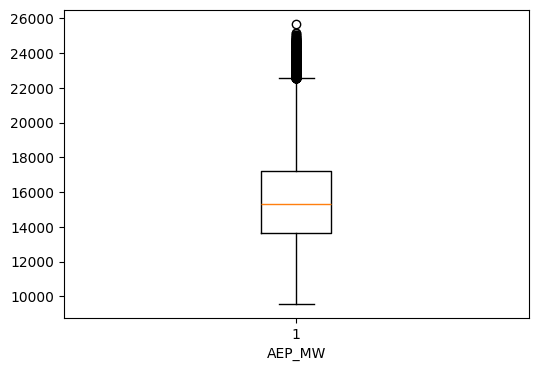

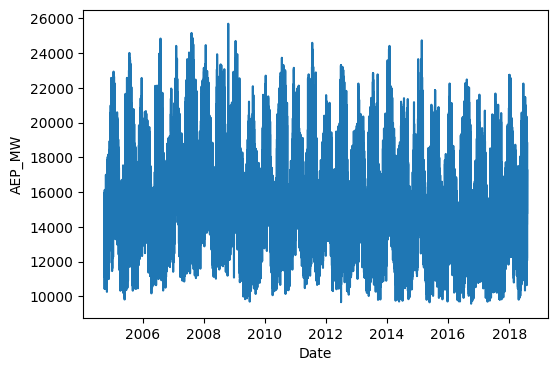

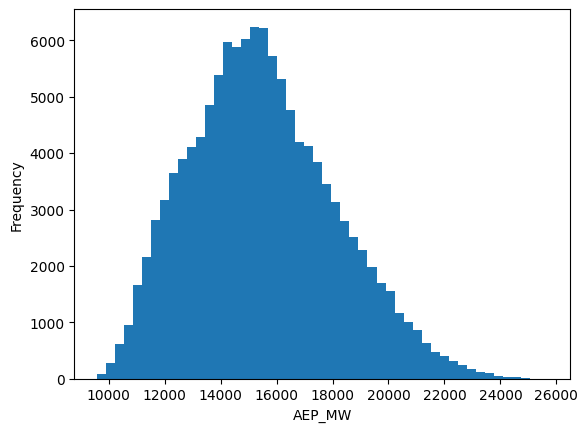

In [3]:
print("Missing values on original data:", df["AEP_MW"].isnull().sum())
print("% missing on original data:", round(df["AEP_MW"].isnull().mean() * 100, 4), "%")

print("\nMissing values on fix_data:", fix_data["AEP_MW"].isnull().sum())
print("% missing on fix_data:", round(fix_data["AEP_MW"].isnull().mean() * 100, 4), "%")

plt.figure(figsize=(6, 4))
plt.boxplot(fix_data["AEP_MW"].dropna(), vert=True)
plt.xlabel("AEP_MW")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(fix_data.index, fix_data["AEP_MW"])
plt.xlabel("Date")
plt.ylabel("AEP_MW")
plt.show()

plt.hist(fix_data["AEP_MW"].dropna(), bins=50)
plt.xlabel("AEP_MW")
plt.ylabel("Frequency")
plt.show()


Write your interpretation here:

- In the original data, there were 27 missing timestamps, which represent 0.022% of the data.
- I do not recognize abnormal or impossible values, or any extreme values that clearly indicate errors.
- According to the boxplot, there are some upper outliers, but they don't seem unusual for electricity consumption data.
- The histogram shows a reasonable distribution, with a slightly longer right tail, which can be expected in electricity consumption due to periods of higher demand.
- Therefore, for now, I would keep these values as they are and not remove them.

---

# Part 4: Basic Statistical EDA

Calculate and explain the following statistics for the electricity consumption variable:

1. Mean
2. Median
3. Minimum
4. Maximum
5. Standard deviation
6. 25%, 50%, and 75% quantiles

Then answer:

1. Is the distribution symmetric or skewed?
2. Are there unusually high or low values?
3. What does the difference between the mean and median suggest?

In [6]:
print(f"Shape: {fix_data.shape}")
fix_data.info()
fix_data.describe()


Shape: (121296, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121296 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121269 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB


,AEP_MW
count,121269.000000
mean,15499.651090
std,2591.325461
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


Write your interpretation here:

- The distribution is slightly right-skewed, because the mean is slightly higher than the median.
- I do not identify unusually low or impossible values. The minimum value is positive and reasonable for electricity consumption.
- There are some high values, but they do not seem abnormal or impossible. They may represent periods of high electricity demand.
- The difference between the mean and median is small, which suggests that the distribution is not strongly skewed. However, since the mean is slightly higher than the median, the data has a mild right tail.

---

# Part 5: Visualizing the Full Time Series

Create a line plot of the full time series.

Answer:

1. Can you identify long-term trends?
2. Are there repeated seasonal patterns?
3. Are there sudden drops or spikes?
4. Does the variance look constant over time?

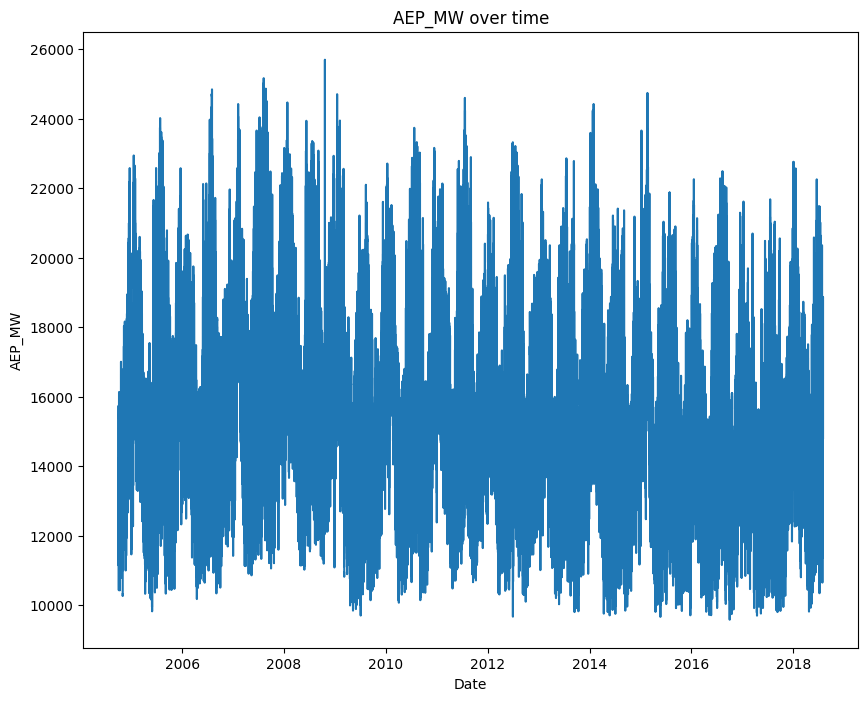

In [8]:
plt.figure(figsize=(10, 8))
plt.plot(fix_data.index, fix_data["AEP_MW"])
plt.xlabel("Date")
plt.ylabel("AEP_MW")
plt.title("AEP_MW over time")
plt.show()

Write your interpretation here:

- There may be some long-term trend, but it is hard to identify clearly over such a long time period because the data is very noisy.
- There are repeated seasonal patterns, with increases and decreases that appear over time.
- There are some spikes and drops, but they do not seem extreme or clearly abnormal.
- The variance looks relatively stable over time. There are some local changes, but nothing very unusual or extreme.

---

# Part 6: Zooming into Specific Time Windows

Select and plot:

1. One full year
2. One full month
3. One full week
4. One full day

Answer:

1. What patterns are easier to see when zooming in?
2. Is there a daily cycle?
3. Is there a weekly cycle?
4. Are weekends different from weekdays?

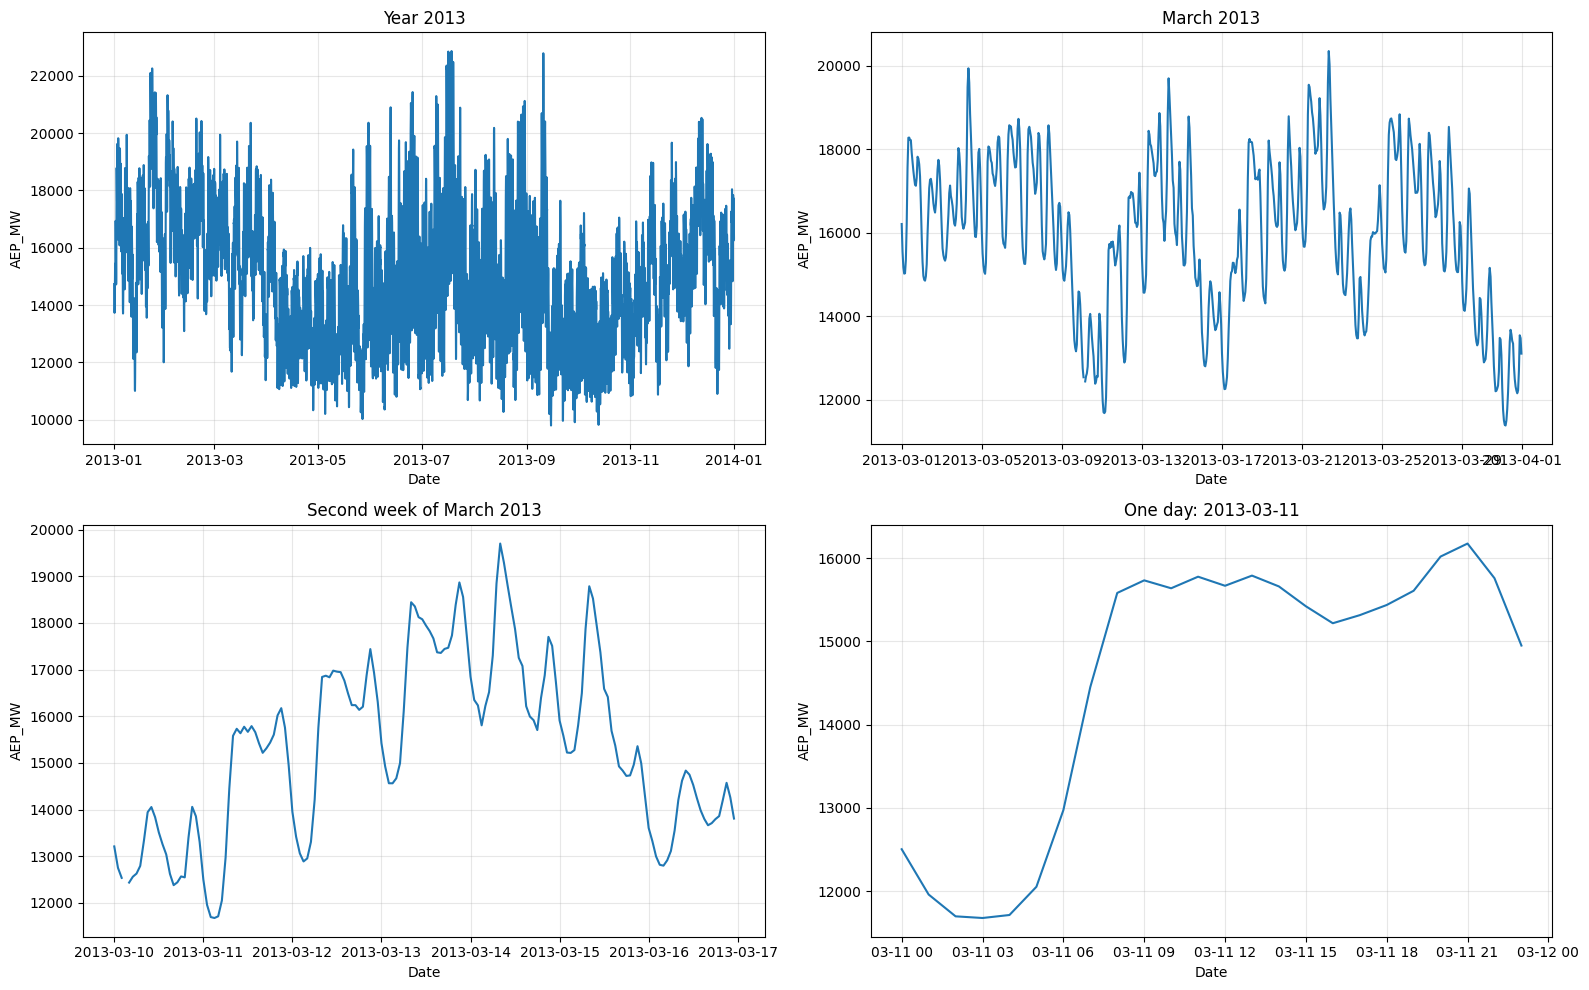

In [14]:
series = fix_data["AEP_MW"]

plots = {
    "Year 2013": series.loc["2013"],
    "March 2013": series.loc["2013-03"],
    "Second week of March 2013": series.loc["2013-03-10":"2013-03-16"],
    "One day: 2013-03-11": series.loc["2013-03-11"]}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (title, data) in zip(axes.flatten(), plots.items()):
    ax.plot(data.index, data.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("AEP_MW")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




Write your interpretation here:

- When zooming in, it is easier to see short-term patterns that are hidden in the full time series, especially daily and weekly changes in electricity consumption.
- There is a clear daily cycle. In the one-day plot, electricity consumption is lower during the night and early morning, then increases during the morning and remains higher during the day and evening.
- There is also a visible weekly cycle. In the monthly and weekly plots, the electricity consumption shows repeated drops approximately every 7 days.
- Weekends seem to be different from weekdays. The repeated drops in the monthly plot, and the lower values in the weekly plot, suggest that electricity consumption is lower during weekends compared to weekdays.

---

# Part 7: Resampling

Resample the hourly data into:

1. Daily average consumption
2. Weekly average consumption
3. Monthly average consumption

Create plots for each resampled series.

Answer:

1. What information is lost when resampling?
2. What information becomes easier to see?
3. Which resampling level is best for identifying long-term trends?
4. Which resampling level is best for identifying short-term behavior?

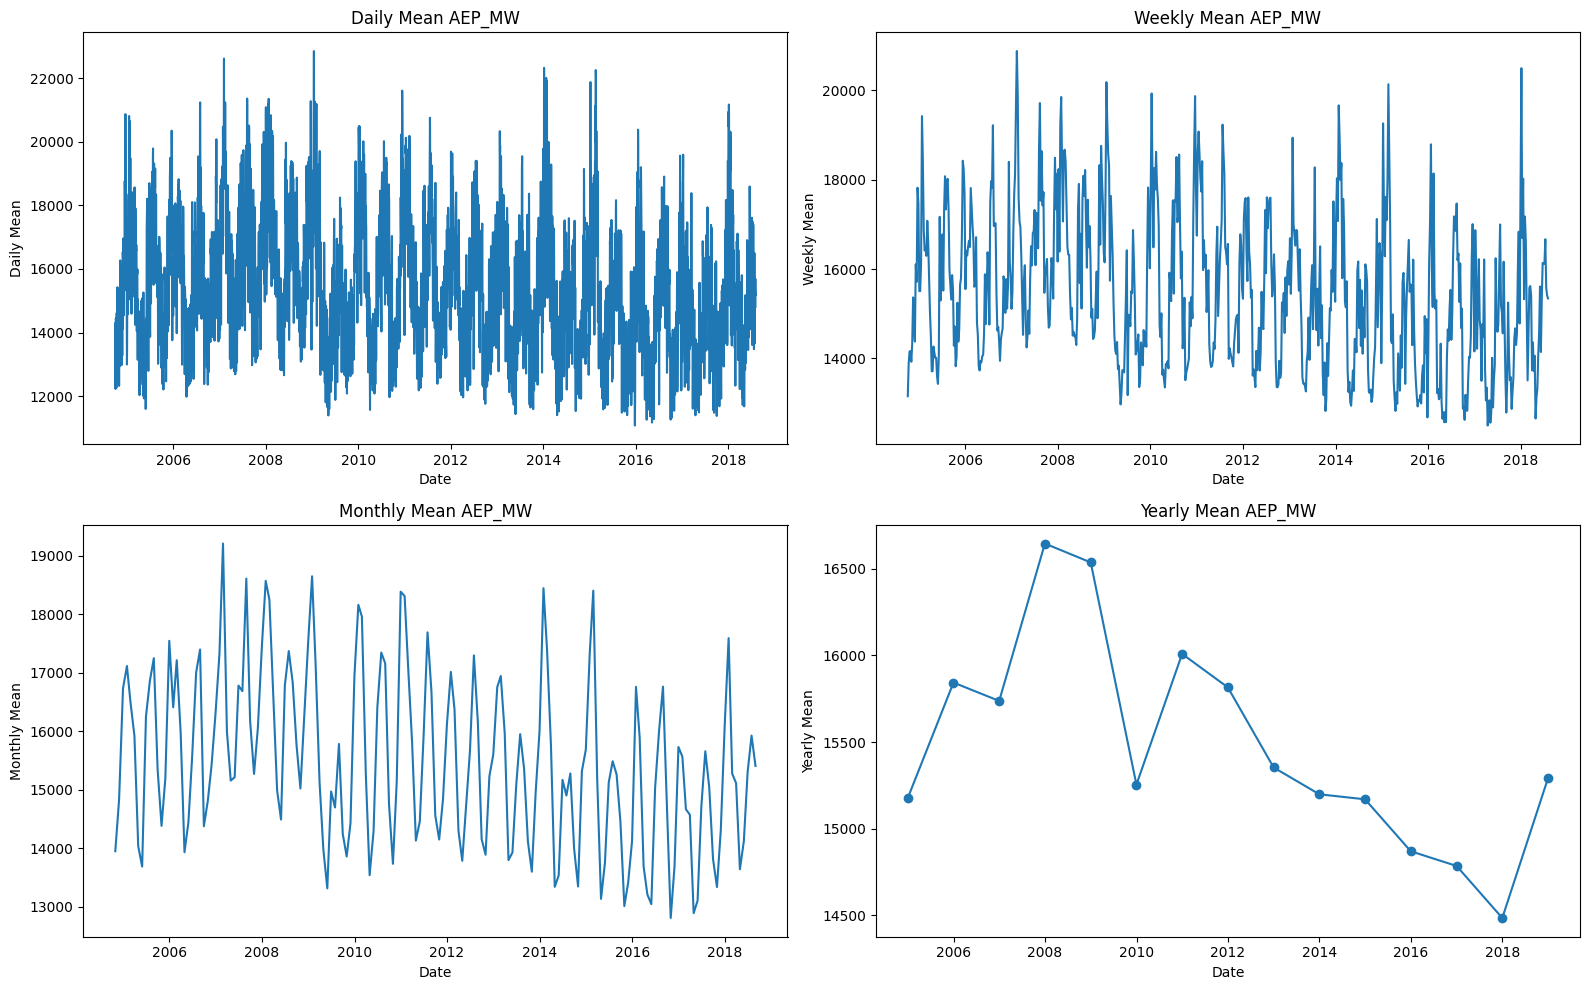

In [16]:
series = fix_data["AEP_MW"]

plots = {
    "Daily Mean AEP_MW": series.resample("D").mean(),
    "Weekly Mean AEP_MW": series.resample("W").mean(),
    "Monthly Mean AEP_MW": series.resample("ME").mean(),
    "Yearly Mean AEP_MW": series.resample("YE").mean()
    }

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (title, data) in zip(axes.flatten(), plots.items()):
    ax.plot(data.index, data.values, marker="o" if "Yearly" in title else None)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(title.replace(" AEP_MW", ""))

plt.tight_layout()
plt.show()

Write your interpretation here:

- When resampling the data, some of the original resolution is lost. For example, after aggregating hourly data into daily, weekly, or monthly values, we can no longer see specific hourly changes, short spikes, peak hours, low-demand hours, or local outliers.

- However, resampling makes the general structure of the time series easier to see. It reduces short-term noise and helps identify seasonality, repeated patterns, and long-term trends.

- The monthly level is useful for identifying long-term trends because it smooths daily and weekly fluctuations while still keeping enough data points to observe changes over time. The yearly level gives a very general picture, but it may hide too much detail.

- For short-term behavior, hourly or daily data is better, especially when zooming in on a specific period. Weekly resampling can show medium-term patterns, but it may be too aggregated for detailed short-term analysis.

---

# Part 8: Seasonality Analysis

Create new time-based features:

1. Hour of day
2. Day of week
3. Month
4. Year

Then create the following plots:

1. Average consumption by hour of day
2. Average consumption by day of week
3. Average consumption by month
4. Average consumption by year

Answer:

1. During which hours is electricity consumption highest?
2. During which hours is it lowest?
3. Which days of the week have higher consumption?
4. Which months have higher consumption?
5. What seasonal patterns do you observe?

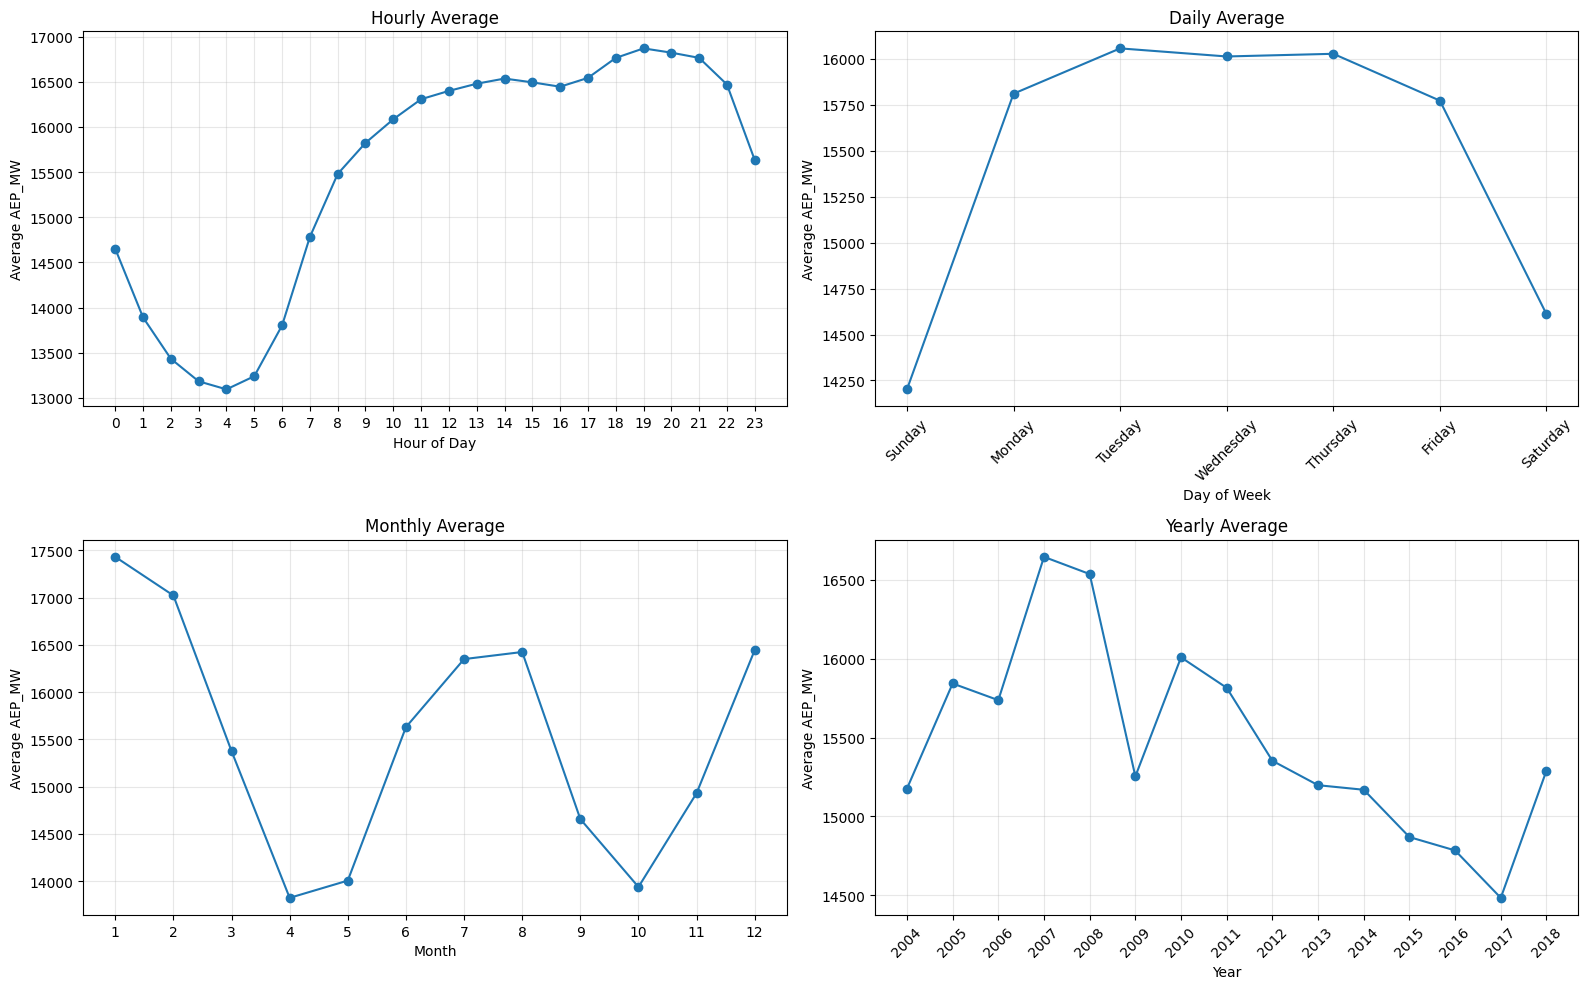

In [18]:
hourly_average = fix_data.groupby(fix_data.index.hour)["AEP_MW"].mean()

daily_average = fix_data.groupby(fix_data.index.day_name())["AEP_MW"].mean()
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
daily_average = daily_average.reindex(day_order)

monthly_average = fix_data.groupby(fix_data.index.month)["AEP_MW"].mean()

yearly_average = fix_data.groupby(fix_data.index.year)["AEP_MW"].mean()



fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly
axes[0, 0].plot(hourly_average.index, hourly_average.values, marker="o")
axes[0, 0].set_title("Hourly Average")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Average AEP_MW")
axes[0, 0].set_xticks(range(24))

# Daily
axes[0, 1].plot(daily_average.index, daily_average.values, marker="o")
axes[0, 1].set_title("Daily Average")
axes[0, 1].set_xlabel("Day of Week")
axes[0, 1].set_ylabel("Average AEP_MW")
axes[0, 1].tick_params(axis="x", rotation=45)

# Monthly
axes[1, 0].plot(monthly_average.index, monthly_average.values, marker="o")
axes[1, 0].set_title("Monthly Average")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Average AEP_MW")
axes[1, 0].set_xticks(range(1, 13))

# Yearly
axes[1, 1].plot(yearly_average.index, yearly_average.values, marker="o")
axes[1, 1].set_title("Yearly Average")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Average AEP_MW")
axes[1, 1].set_xticks(yearly_average.index)
axes[1, 1].tick_params(axis="x", rotation=45)

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




Write your interpretation here:

- Electricity consumption is lower during the night and early morning. Around 6-7 AM, the average consumption starts to increase, and it remains relatively high throughout the day. Another increase can be seen in the late afternoon and evening, with the highest average values around 7-8 PM.

- During weekdays, electricity consumption is relatively stable and higher on average. On weekends, especially Sunday and Saturday, the average consumption is lower.

- Monthly electricity consumption is higher on average during the winter months, especially December to February, and also during the summer months, mainly July and August.

- Overall, the data shows clear daily, weekly, and monthly patterns.

---

# Part 9: Distribution Analysis

Create:

1. Histogram of electricity consumption
2. Boxplot of electricity consumption
3. Boxplot by hour
4. Boxplot by month

Answer:

1. Is the distribution normal?
2. Are there many outliers?
3. Which hours have the largest variability?
4. Which months have the largest variability?

Write your interpretation here:

- ...

---

# Part 10: Autocorrelation

Plot the autocorrelation of the electricity consumption series.

Answer:

1. Is the series autocorrelated?
2. Do nearby observations depend on each other?
3. Can you identify daily seasonality?
4. Can you identify weekly seasonality?
5. Why is autocorrelation important for time series forecasting?

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Write your interpretation here:

- ...

---

# Part 11: Stationarity Test

Use the Augmented Dickey-Fuller test.

Answer:

1. What is the null hypothesis of the ADF test?
2. What is the p-value?
3. Is the time series stationary?
4. Why does stationarity matter in time series analysis?
5. What transformations could make the series more stationary?

In [30]:
from statsmodels.tsa.stattools import adfuller


Write your interpretation here:

- ...

---

# Part 12: Rolling Statistics

Calculate and plot:

1. 24-hour rolling mean
2. 7-day rolling mean
3. 30-day rolling mean
4. 24-hour rolling standard deviation

Answer:

1. What does the rolling mean reveal?
2. What does the rolling standard deviation reveal?
3. Does the variability change over time?
4. Are there periods with unusually high or low demand?

Write your interpretation here:

- ...

---

# Part 13: Decomposition

Use seasonal decomposition on a daily or monthly resampled series.

Answer:

1. What does the trend component show?
2. What does the seasonal component show?
3. What does the residual component show?
4. Does an additive decomposition seem appropriate?
5. Would a multiplicative decomposition be better? Explain.

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

Write your interpretation here:

- ...

---

# Part 14: Summary and Conclusions

Write a short EDA report, about 1-2 pages, that includes:

1. Description of the dataset
2. Time range and frequency
3. Missing values and data quality issues
4. Main trends
5. Main seasonal patterns
6. Distribution and outliers
7. Autocorrelation findings
8. Stationarity test conclusion
9. Recommendations for preprocessing before forecasting

## Final EDA Report

Write your final report here.

### Dataset Description

...

### Time Range and Frequency

...

### Missing Values and Data Quality

...

### Trends and Seasonality

...

### Distribution and Outliers

...

### Autocorrelation and Stationarity

...

### Recommendations Before Forecasting

...

---

# Optional Extension - Bonus

Students who want an additional challenge may compare the AEP series with another electricity region from the same Kaggle dataset.

Compare:

1. Mean consumption
2. Seasonal patterns
3. Autocorrelation
4. Stationarity
5. Volatility over time

---

# Submission Instructions

Submit:

1. A Jupyter Notebook with all code, plots, and explanations.
2. A short written summary at the end of the notebook.
3. The notebook should be clean, organized, and divided into sections.
4. All plots must include titles and axis labels.
5. Every major result should be followed by a short explanation.